In [5]:
from google.colab import drive, auth
import pandas as pd
import os

# Try authenticating first before mounting
try:
    auth.authenticate_user()
    drive.mount('/content/drive', force_remount=True)
    print("Drive mounted successfully.")
except Exception as e:
    print(f"Authentication or mounting failed: {e}")

# Updated path for your PDF
file_path = '/content/drive/MyDrive/Lab-10-PCA.pdf'

if os.path.exists(file_path):
    print(f"File found at: {file_path}")
else:
    print("File not found in Drive. Please check if the file is in 'MyDrive'.")

Authentication or mounting failed: Error: credential propagation was unsuccessful
File not found in Drive. Please check if the file is in 'MyDrive'.


In [3]:
import pandas as pd

# Loading the heart.csv file
file_path_csv = '/content/heart.csv'

try:
    df_heart = pd.read_csv(file_path_csv)
    print('Data loaded successfully!')
    display(df_heart.head())
except Exception as e:
    print(f'Error loading CSV: {e}')

Data loaded successfully!


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


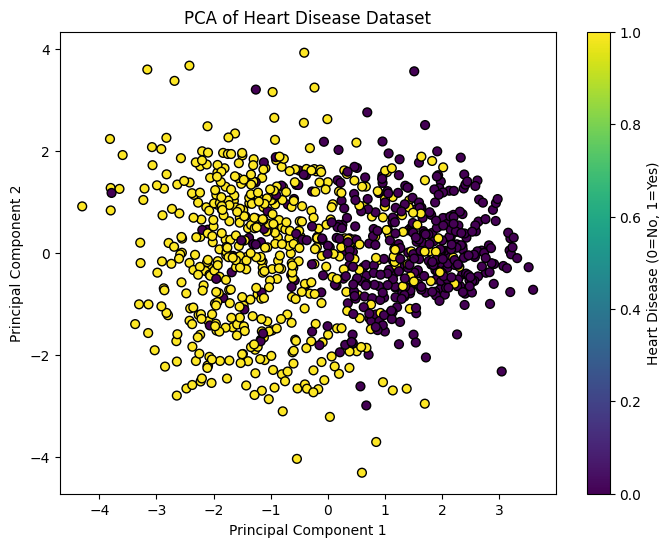

Explained variance ratio: [0.25139665 0.1330889 ]


In [9]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Preprocessing: Encode categorical variables
le = LabelEncoder()
df_numeric = df_heart.copy()
for col in df_numeric.select_dtypes(include=['object']).columns:
    df_numeric[col] = le.fit_transform(df_numeric[col])

# 2. Scaling the data
X = df_numeric.drop('HeartDisease', axis=1)
y = df_numeric['HeartDisease']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Applying PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# Plotting the results
plt.figure(figsize=(8, 6))
plt.scatter(components[:, 0], components[:, 1], c=y, cmap='viridis', edgecolor='k', s=40)
plt.title('PCA of Heart Disease Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Heart Disease (0=No, 1=Yes)')
plt.show()

print(f'Explained variance ratio: {pca.explained_variance_ratio_}')

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Preprocessing (One-Hot Encoding for categorical features)
df_encoded = pd.get_dummies(df_heart, drop_first=True)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# 2. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define Models
models = {
    'SVM': SVC(),
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100)
}

print("--- Performance with ALL Features ---")
results_full = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results_full[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

--- Performance with ALL Features ---
SVM Accuracy: 0.8750
Logistic Regression Accuracy: 0.8533
Random Forest Accuracy: 0.8641


In [11]:
# 3. Apply PCA
# We will choose enough components to explain 90% of the variance
pca_90 = PCA(n_components=0.90)
X_pca = pca_90.fit_transform(X_scaled)

# Split PCA data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

print(f"\nNumber of components explaining 90% variance: {pca_90.n_components_}")
print("--- Performance with PCA Features ---")
results_pca = {}
for name, model in models.items():
    model.fit(X_train_pca, y_train_pca)
    preds = model.predict(X_test_pca)
    acc = accuracy_score(y_test_pca, preds)
    results_pca[name] = acc
    print(f"{name} (PCA) Accuracy: {acc:.4f}")


Number of components explaining 90% variance: 11
--- Performance with PCA Features ---
SVM (PCA) Accuracy: 0.8750
Logistic Regression (PCA) Accuracy: 0.8533
Random Forest (PCA) Accuracy: 0.8478


### Observation Book: Heart Disease Dataset PCA Analysis

**1. Accuracy Scores Comparison**

| Model | Accuracy (Before PCA) | Accuracy (After PCA) |
| :--- | :--- | :--- |
| **SVM** | 87.50% | 87.50% |
| **Logistic Regression** | 85.33% | 85.33% |
| **Random Forest** | 86.41% | 84.78% |

**Observation:**
- The **SVM** and **Logistic Regression** models maintained identical accuracy after PCA, even though the feature space was reduced to 11 components.
- The **Random Forest** model saw a slight decrease in accuracy (~1.63%), which is expected as PCA can sometimes remove specific feature interactions that tree-based models rely on.